In [92]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from evoscape.landscapes import Landscape
from evoscape.modules import Node
from evoscape.morphogen_regimes import mr_const
from evoscape.landscape_visuals import plot_traj, visualize_landscape
from evoscape.jax.experiment import Experiment

plt.style.use("default")

In [93]:
modules = (
    Node(x=1.5, y=0.0, a=np.array([1.5]), s=np.array([1.0])),
    Node(x=-1.5, y=0.0, a=np.array([1.5]), s=np.array([1.0])),
)

landscape = Landscape(
    module_list=modules,
    A0=0.05,
    init_cond=(0.0, 0.0),
    regime=mr_const,
    n_regimes=1,
    morphogen_times=(),
)

experiment = Experiment(landscape)

n_cells = 200
q0 = np.vstack((
    np.linspace(-1, 1, n_cells),
    np.ones(n_cells),
))

experiment.set_initial_conditions(q0)
experiment.set_regime("const")
experiment.set_simulation(t0=0.0, tf=3.0, nt=10, ndt=50, noise=0.2)

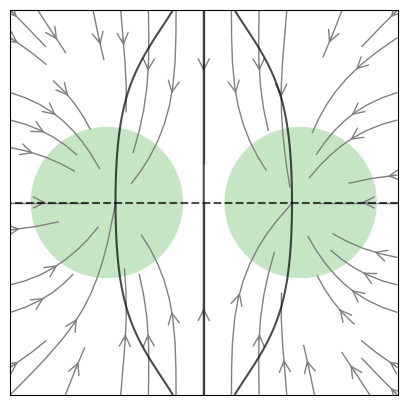

In [94]:

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

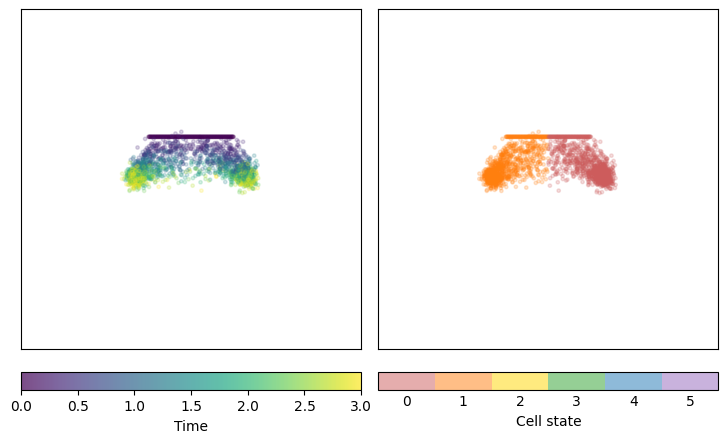

In [95]:
traj, states, t0, tf, nt = experiment.get_trajectory(seed=0)
fig = plot_traj(traj, states, t0, tf, nt, L=4)
plt.show()

In [96]:
np.mean(states[:, :, -1], axis=1)

Array([0.51025116, 0.48974887], dtype=float32)

Landscape with modules:
Node: x=1.4335954189300537; y=0.03471656143665314; a=[1.558355]; s=[1.207446],
Node: x=-1.550521969795227; y=-0.040375594049692154; a=[1.4415405]; s=[1.0004324]


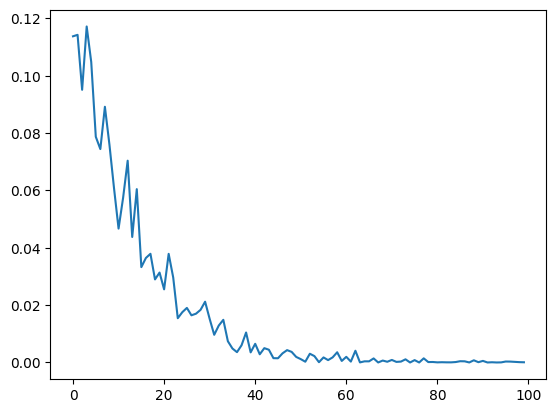

In [97]:
# def user_fitness(traj, states):
#     return jnp.var(traj[0, :, -1])

# def user_fitness(traj, states):
#     final_coordinates = traj[:, :, -1]
#     return jnp.sum(final_coordinates ** 2)

def user_fitness(traj, states):
    final_states = np.mean(states[:, :, -1], axis=1) # avg over cells
    # using target proportion 75% / 25%
    return jnp.sum((final_states - jnp.array((0.75, 0.25))) ** 2)



losses = experiment.optimize(user_fitness, steps=100, lr=0.01, seed=0)
optimized_landscape = experiment.get_landscape()

plt.plot(losses)
print(optimized_landscape)

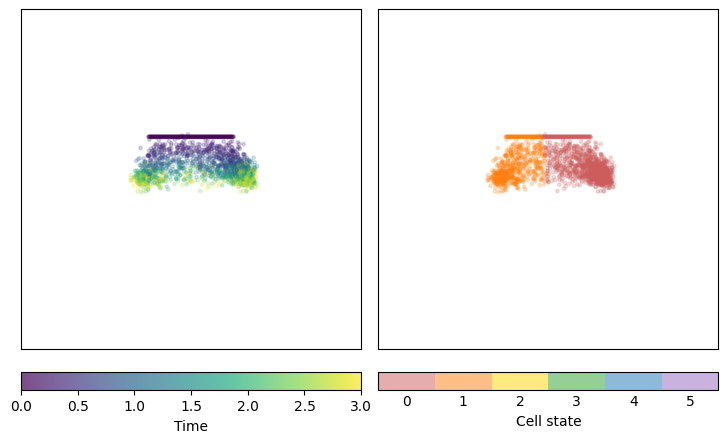

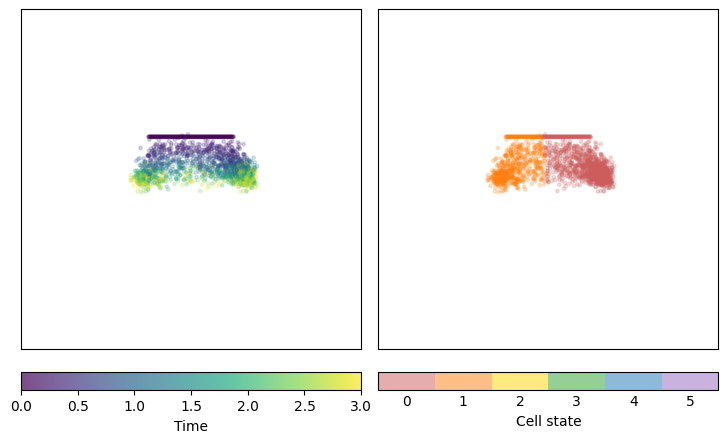

In [98]:
traj, states, t0, tf, nt = experiment.get_trajectory(seed=0)
fig = plot_traj(traj, states, t0, tf, nt, L=4)
fig

In [99]:
np.mean(states[:, :, -1], axis=1)

Array([0.74936837, 0.25063163], dtype=float32)

Landscape with modules:
Node: x=1.4335954189300537; y=0.03471656143665314; a=[1.558355]; s=[1.207446],
Node: x=-1.550521969795227; y=-0.040375594049692154; a=[1.4415405]; s=[1.0004324]


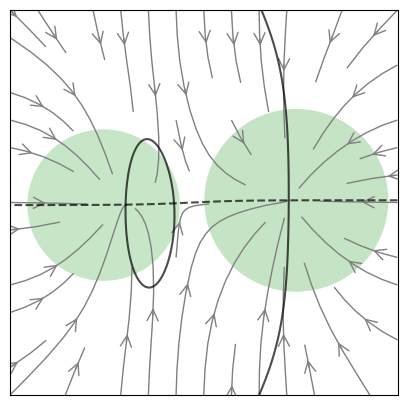

In [100]:
l = experiment.get_landscape()


print(l)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')